# #PCA: Principal Component Analysis
- converts suppose here , 8 dimensional data to 2D or 3D.
- dimensionality reduction algorithm

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

In [40]:
# Loading the dataset again, loading x_scaled again cuz we need it obv
import pandas as pd

df = pd.read_csv("../data/spotify_tracks_clustered.csv")
print(df.shape)
df.head()

(114000, 16)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,5
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,1
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,1
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,1
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,1


In [41]:
# Select features
feature_cols = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo"
]

X = df[feature_cols]

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# fit = PCA learns the best 2 directions in your 8-feature space
# transform: converts the data into PCA coordinates
#----------- each song becomes: 
#            PC1 value
#            PC2 value
#            x_pca we call this

In [43]:
# Till now we loaded , scaled the file we're gonna use
# Now we do PCA below.

In [44]:
pca = PCA(n_components=2) #this will create 2D

In [45]:
X_pca = pca.fit_transform(X_scaled) #

In [46]:
# To just check
print(X_scaled.shape)
print(X_pca.shape)

(114000, 8)
(114000, 2)


In [47]:
print(pca.explained_variance_ratio_)

[0.27509217 0.17681248]


In [48]:
# As the x_pca is in numpy arrays - convert it into df
pca_df= pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["cluster"]= df["cluster"]
# above line means: Add the cluster label of each song into the PCA dataframe.
# each dot = a song
# color = cluster
pca_df.head()

,PC1,PC2,cluster
0,0.669634,1.012689,5
1,-2.796218,1.204504,1
2,-1.544585,-0.012545,1
3,-2.740799,-0.515934,1
4,-1.019658,0.380313,1


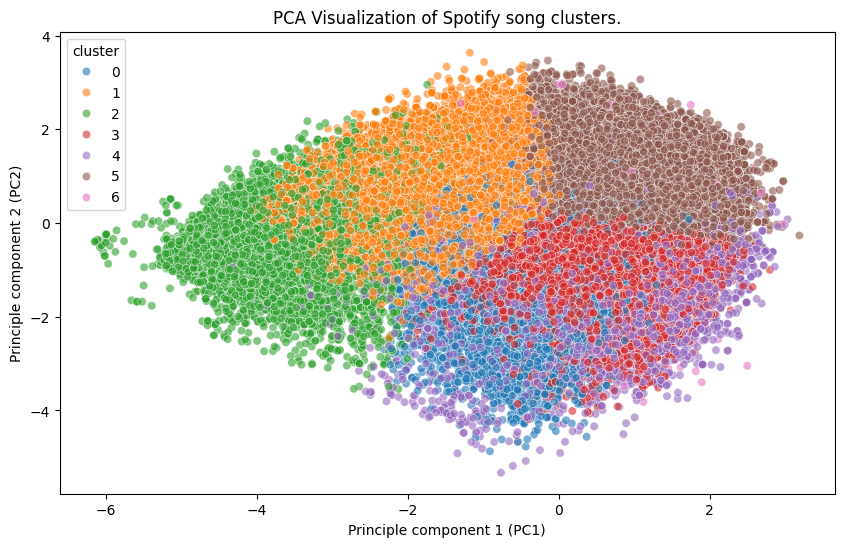

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x= "PC1",
    y= "PC2",
    hue= "cluster",
    palette= "tab10",
    alpha= 0.6

)

plt.title("PCA Visualization of Spotify song clusters.")
plt.xlabel("Principle component 1 (PC1)")
plt.ylabel("Principle component 2 (PC2)")
plt.legend(title="cluster")
plt.show()

# # Cluster Interpretation Notes

In [50]:
# Finding mean(average): to find waht a typical song looks like in a particular cluster.
cluster_means=df.groupby("cluster")[feature_cols].mean()
cluster_means

,danceability,energy,valence,acousticness,instrumentalness,speechiness,liveness,tempo
cluster,,,,,,,,
0,0.585570,0.757270,0.338454,0.088463,0.786379,0.072118,0.172209,127.702535
1,0.520349,0.372103,0.376548,0.692899,0.020667,0.051409,0.156332,112.314661
2,0.367677,0.189541,0.203960,0.856923,0.843823,0.051172,0.152683,103.762211
3,0.473881,0.807849,0.371552,0.073351,0.031414,0.082771,0.190941,139.723268
4,0.519497,0.748116,0.507470,0.290408,0.070106,0.086623,0.737977,123.289989
5,0.705146,0.716016,0.695650,0.213458,0.019084,0.093560,0.164338,117.854693
6,0.575431,0.669989,0.446394,0.717210,0.010766,0.821571,0.636953,102.057166


- Cluster 0: High energy + Very high instrumentalness + Low acousticness + Medium-high tempo 
 : Instrumental electronic / background beats / gym-style instrumentals

- Cluster 1: High acousticness + Low energy + Very low instrumentalness + Medium tempo 
 : Calm acoustic/pop songs, soft vocals, chill mood

- Cluster 2: Highest acousticness + Highest instrumentalness + Lowest energy + Lowest danceability + Low tempo 
 : Ambient / classical / background instrumental music (very calm, low intensity)

- Cluster 3: Highest energy + Highest tempo + Lowest acousticness
 : Fast EDM / rock / workout music (high intensity, energetic)

- Cluster 4: Highest liveness + High energy + Medium tempo 
 : Concert/live recordings, crowd presence, stage performance feel

- Cluster 5: Highest danceability + Highest valence + High energy
 : Party pop / upbeat dance music (happy, positive vibe)

- Cluster 6: Extremely high speechiness + High acousticness + High liveness + Lowest tempo 
 : Rap / spoken-word / podcast-like tracks (strong vocals, speech-heavy)